In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('figures', exist_ok=True)

In [15]:
spy = yf.download('SPY', start='2019-01-01', end='2025-01-01')
spy.columns = spy.columns.get_level_values(0)  # flatten multi-level columns
spy['Return'] = 100 * spy['Close'].pct_change()
spy = spy.dropna()

[*********************100%***********************]  1 of 1 completed


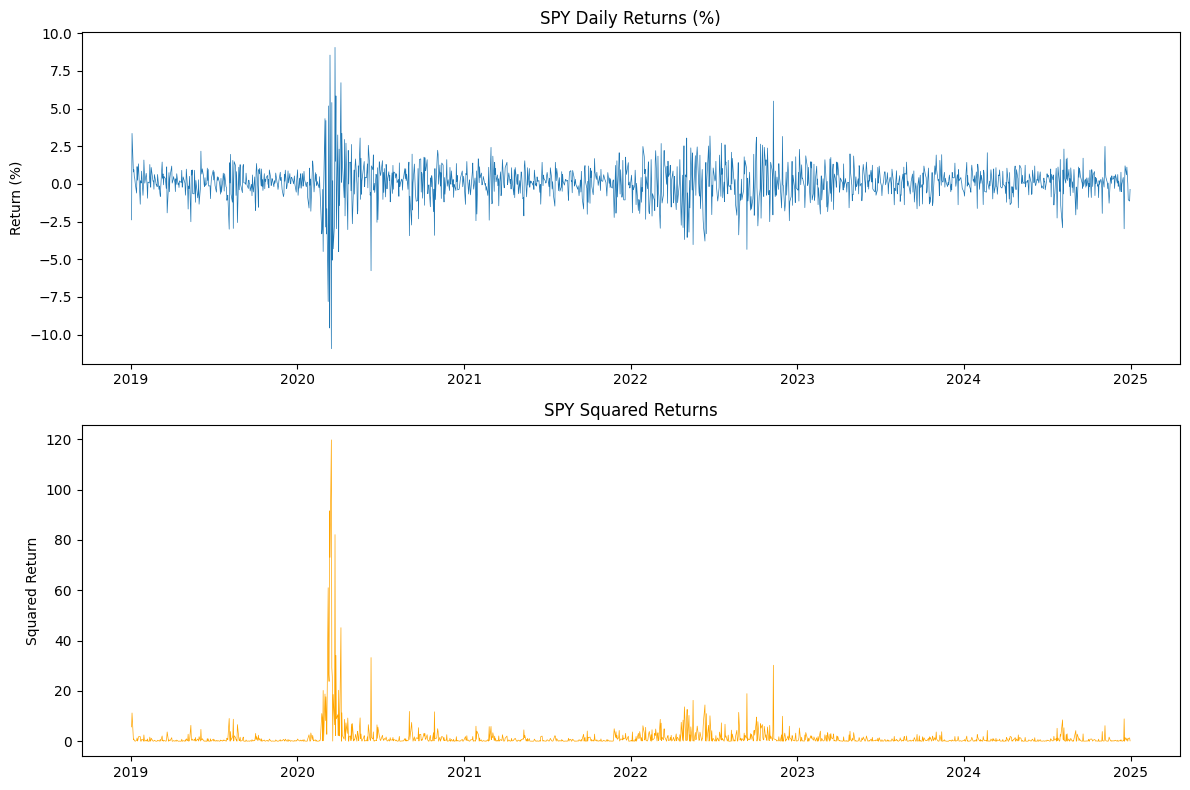

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(spy.index, spy['Return'], linewidth=0.5)
axes[0].set_title('SPY Daily Returns (%)')
axes[0].set_ylabel('Return (%)')

axes[1].plot(spy.index, spy['Return']**2, linewidth=0.5, color='orange')
axes[1].set_title('SPY Squared Returns')
axes[1].set_ylabel('Squared Return')
plt.tight_layout()
plt.savefig('figures/returns_and_squared.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
model = arch_model(spy['Return'], vol='Garch', p=1, q=1, mean='Constant', dist='normal')
result = model.fit(disp='off')
print(result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                 Return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2098.99
Distribution:                  Normal   AIC:                           4205.97
Method:            Maximum Likelihood   BIC:                           4227.25
                                        No. Observations:                 1509
Date:                Wed, Mar 11 2026   Df Residuals:                     1508
Time:                        22:59:50   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1056  2.126e-02      4.967  6.810e-07 [6.393e-0

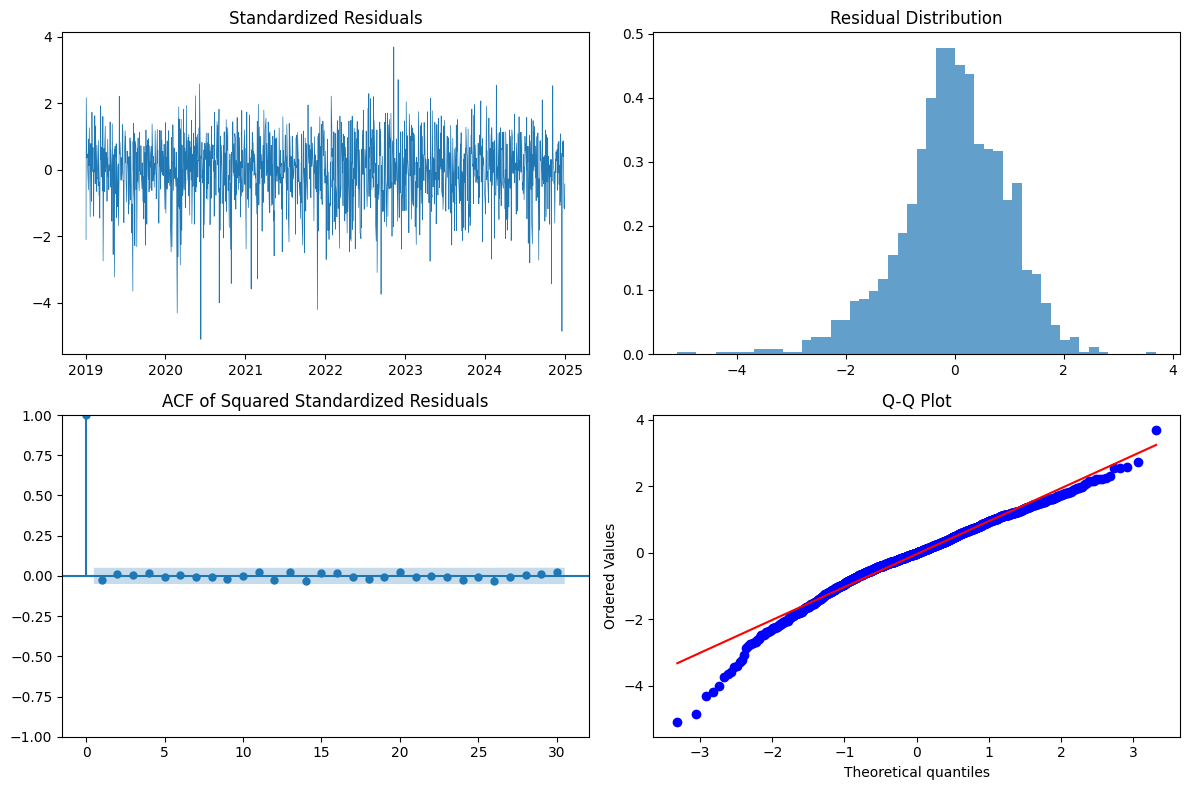

In [18]:
std_resid = result.resid / result.conditional_volatility

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(std_resid, linewidth=0.5)
axes[0, 0].set_title('Standardized Residuals')

axes[0, 1].hist(std_resid, bins=50, density=True, alpha=0.7)
axes[0, 1].set_title('Residual Distribution')

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(std_resid**2, lags=30, ax=axes[1, 0])
axes[1, 0].set_title('ACF of Squared Standardized Residuals')

from scipy.stats import probplot
probplot(std_resid, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')

plt.tight_layout()
plt.savefig('figures/garch_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Ljung-Box on squared standardized residuals
lb_test = acorr_ljungbox(std_resid**2, lags=[10, 20, 30], return_df=True)
print("Ljung-Box test on squared standardized residuals:")
print(lb_test)
print()

# Jarque-Bera on standardized residuals
jb_result = jarque_bera(std_resid)
print(f"Jarque-Bera: stat={jb_result.statistic:.2f}, p={jb_result.pvalue:.4f}")
print(f"Skewness: {std_resid.skew():.4f}, Kurtosis: {std_resid.kurtosis() + 3:.4f}")


Ljung-Box test on squared standardized residuals:
      lb_stat  lb_pvalue
10   2.615917   0.989077
20   9.575525   0.975232
30  13.838154   0.994834

Jarque-Bera: stat=238.52, p=0.0000
Skewness: -0.6061, Kurtosis: 4.5346


## Key Findings

- GARCH(1,1) parameters: omega=___, alpha=___, beta=___
- Persistence (alpha + beta): ___
- Ljung-Box on squared standardized residuals: p=___ (compare to ARIMA squared residuals)
- Jarque-Bera: p=___, skewness=___, kurtosis=___
- Conditional volatility captures COVID spike and subsequent regimes
- Remaining fat tails and negative skewness motivate asymmetric models (EGARCH, GJR-GARCH)

In [ ]:
# %% Out-of-Sample Volatility Forecasting

# Split data
split_date = '2024-01-01'
train_returns = spy['Return'][spy.index < split_date]
test_returns = spy['Return'][spy.index >= split_date]

print(f"Train: {train_returns.index[0].date()} to {train_returns.index[-1].date()} ({len(train_returns)} obs)")
print(f"Test: {test_returns.index[0].date()} to {test_returns.index[-1].date()} ({len(test_returns)} obs)")

Train: 2019-01-03 to 2023-12-29 (1257 obs)
Test: 2024-01-02 to 2024-12-31 (252 obs)


In [ ]:
# Fit models on training data only, forecast over test period
full_garch = arch_model(spy['Return'], vol='GARCH', p=1, q=1, mean='Constant')
full_garch_fit = full_garch.fit(last_obs=split_date, disp='off')

full_gjr = arch_model(spy['Return'], vol='GARCH', p=1, o=1, q=1, mean='Constant')
full_gjr_fit = full_gjr.fit(last_obs=split_date, disp='off')

print("GARCH(1,1) params (trained on pre-2024):")
print(full_garch_fit.params)
print(f"\nGJR-GARCH(1,1) params (trained on pre-2024):")
print(full_gjr_fit.params)

NameError: name 'returns' is not defined

In [ ]:
# One-step-ahead forecasts over test period
garch_forecast = full_garch_fit.forecast(horizon=1, start=split_date, align='target')
gjr_forecast = full_gjr_fit.forecast(horizon=1, start=split_date, align='target')

# Conditional vol in decimal returns (undo the *100 scaling)
garch_cond_vol = np.sqrt(garch_forecast.variance.dropna()) / 100
gjr_cond_vol = np.sqrt(gjr_forecast.variance.dropna()) / 100

NameError: name 'full_garch_fit' is not defined

In [ ]:
# Realized volatility benchmark: rolling 21-day std of decimal returns
realized_vol = (spy['Return'] / 100).rolling(window=21).std()
realized_vol_test = realized_vol[realized_vol.index >= split_date]

NameError: name 'returns' is not defined

NameError: name 'realized_vol_test' is not defined

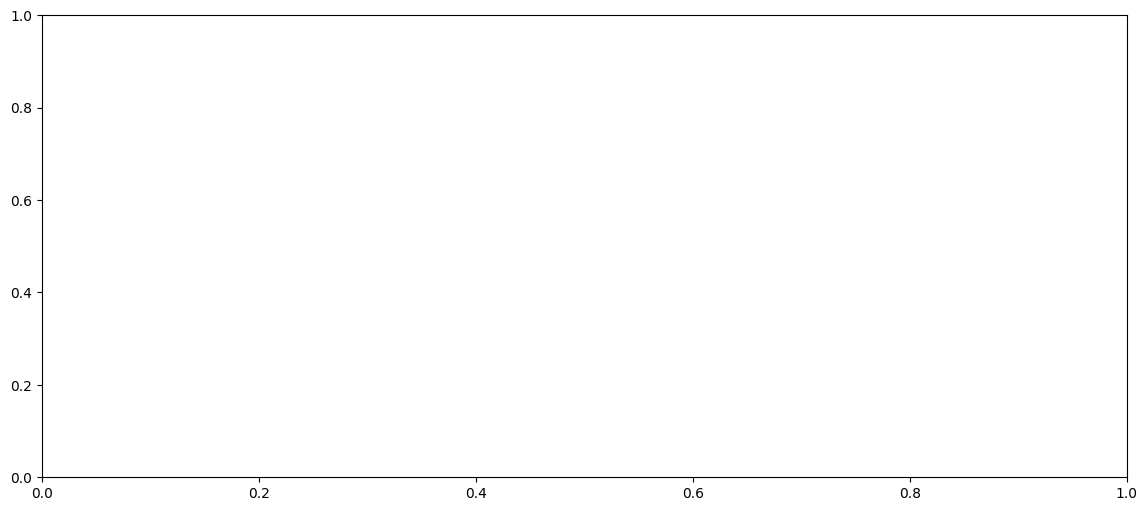

In [ ]:
# Plot: conditional vol vs realized vol
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(realized_vol_test.index, realized_vol_test.values, color='black', alpha=0.5, linewidth=1, label='Realized Vol (21-day)')
ax.plot(garch_cond_vol.index, garch_cond_vol.values, color='blue', linewidth=1, label='GARCH(1,1) Conditional Vol')
ax.plot(gjr_cond_vol.index, gjr_cond_vol.values, color='red', linewidth=1, label='GJR-GARCH(1,1) Conditional Vol')

ax.set_title('Out-of-Sample Conditional Volatility vs Realized Volatility (2024-2025)', fontsize=13)
ax.set_ylabel('Volatility (daily, decimal)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/oos_volatility_forecast.png', dpi=150)
plt.show()

In [ ]:
# Multi-step ahead variance term structure (10-day horizon)
garch_multi = full_garch_fit.forecast(horizon=10)
gjr_multi = full_gjr_fit.forecast(horizon=10)

# Variance at each horizon, rescaled to decimal, annualized
garch_var_term = garch_multi.variance.iloc[-1].values / (100**2)
gjr_var_term = gjr_multi.variance.iloc[-1].values / (100**2)

garch_vol_term = np.sqrt(garch_var_term) * np.sqrt(252)
gjr_vol_term = np.sqrt(gjr_var_term) * np.sqrt(252)

fig, ax = plt.subplots(figsize=(10, 5))
horizons = range(1, 11)
ax.plot(horizons, garch_vol_term, 'b-o', label='GARCH(1,1)')
ax.plot(horizons, gjr_vol_term, 'r-o', label='GJR-GARCH(1,1)')
ax.set_xlabel('Forecast Horizon (days)')
ax.set_ylabel('Annualized Volatility')
ax.set_title('Variance Term Structure: Multi-Step Ahead Forecast', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/variance_term_structure.png', dpi=150)
plt.show()

NameError: name 'full_garch_fit' is not defined

In [ ]:
# RMSE comparison
from sklearn.metrics import mean_squared_error

common_idx = realized_vol_test.dropna().index.intersection(garch_cond_vol.index).intersection(gjr_cond_vol.index)

rv = realized_vol_test.loc[common_idx].values.flatten()
gv = garch_cond_vol.loc[common_idx].values.flatten()
gjrv = gjr_cond_vol.loc[common_idx].values.flatten()

rmse_garch = np.sqrt(mean_squared_error(rv, gv))
rmse_gjr = np.sqrt(mean_squared_error(rv, gjrv))

print(f"RMSE vs Realized Vol (21-day):")
print(f"  GARCH(1,1):     {rmse_garch:.6f}")
print(f"  GJR-GARCH(1,1): {rmse_gjr:.6f}")
print(f"  Difference:     {abs(rmse_garch - rmse_gjr):.6f} ({'GJR wins' if rmse_gjr < rmse_garch else 'GARCH wins'})")

ModuleNotFoundError: No module named 'sklearn'